# E1-S3 to E1-S6 — Data Foundation & Regime Construction

## tl;dr

- Published **5,165** canonical SPY daily rows from **2006-02-01** through **2026-08-13**.
- The dataset contains **11 frozen historical features**, `forward_return_5d`, and a leakage-safe `regime`; admitted rows have no missing or infinite values.
- Regime coverage: **2,590 LowVol (50.1%)** and **2,575 HighVol (49.9%)**.
- Manual formula checks, five-trading-row target alignment, past-only regime thresholds, raw immutability, CSV round-trip, schema, dtype, and index gates all pass.

**Research question:** Does a LightGBM signal for SPY five-trading-day forward returns show different genuine out-of-sample performance in Low-Vol versus High-Vol regimes?


## Context & Methods

This notebook implements the following Trello cards using the exact card IDs as section names:

- [E1-S3 — Build Returns & 5-Trading-Day Forward Target](https://trello.com/c/dRR58WDg)
- [E1-S4 — Build Historical Feature Set](https://trello.com/c/1nBr3JrS)
- [E1-S5 — Construct Leakage-Safe Low/High Volatility Regime](https://trello.com/c/G8hsrnJR)
- [E1-S6 — Publish Canonical Modeling Dataset & Data Dictionary](https://trello.com/c/4wwdJQnv)

### Key Assumptions

- SPY prices use the `yfinance auto_adjust=True` convention established in E1-S1.
- All rolling features use only rows at or before prediction date $t$; no centered windows, backfill, or future-informed preprocessing is used.
- Volatility features are annualized rolling sample standard deviations (`ddof=1`, 252 trading days/year).
- The regime threshold at $t$ is the expanding median of available 20-day realized volatility values strictly before $t$, after at least 252 historical volatility observations.
- Equality with the threshold is classified as `HighVol`; no smoothing or post-result rule changes are applied.


In [1]:
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DOCS_DIR = PROJECT_ROOT / "docs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

TICKER = "SPY"
START_DATE = "2005-01-01"
END_DATE = None
AUTO_ADJUST = True
TRADING_DAYS_PER_YEAR = 252
RANDOM_STATE = 42

RAW_CSV_PATH = RAW_DIR / "E1-S1_SPY_OHLCV_auto_adjusted.csv"
RAW_PROVENANCE_PATH = RAW_DIR / "E1-S1_SPY_OHLCV_auto_adjusted.provenance.json"
CANONICAL_CSV_PATH = PROCESSED_DIR / "E1-S6_canonical_modeling_dataset.csv"
MANIFEST_PATH = PROCESSED_DIR / "E1-S6_dataset_manifest.json"
DATA_DICTIONARY_PATH = DOCS_DIR / "E1-S6_data_dictionary.csv"


## E1-S1 [P0][Data] Acquire & Version Raw SPY OHLCV

The first successful run downloads and freezes the raw artifact. Later runs reuse the committed raw CSV instead of silently replacing it with provider-revised history.


In [2]:
OHLCV_COLUMNS = ["Open", "High", "Low", "Close", "Volume"]

if RAW_CSV_PATH.exists():
    if not RAW_PROVENANCE_PATH.exists():
        raise FileNotFoundError(
            f"Raw data exists without provenance: {RAW_PROVENANCE_PATH}"
        )
    raw = pd.read_csv(RAW_CSV_PATH, parse_dates=["Date"]).set_index("Date")
    raw = raw[OHLCV_COLUMNS]
    source_mode = "immutable committed raw artifact"
    acquisition_provenance = json.loads(RAW_PROVENANCE_PATH.read_text())
else:
    raw = yf.download(
        TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=AUTO_ADJUST,
        progress=False,
    )
    if raw.empty:
        raise RuntimeError("yfinance returned an empty SPY dataset")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw[OHLCV_COLUMNS].copy()
    raw.index = pd.DatetimeIndex(raw.index).tz_localize(None)
    raw.index.name = "Date"
    raw.to_csv(RAW_CSV_PATH, date_format="%Y-%m-%d")

    acquisition_provenance = {
        "card": "E1-S1 [P0][Data] Acquire & Version Raw SPY OHLCV",
        "ticker": TICKER,
        "provider": "Yahoo Finance via yfinance",
        "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
        "requested_start_date": START_DATE,
        "requested_end_date": END_DATE,
        "auto_adjust": AUTO_ADJUST,
        "price_convention": "auto-adjusted OHLC; volume from yfinance",
        "rows": int(len(raw)),
        "first_trading_date": raw.index.min().date().isoformat(),
        "last_trading_date": raw.index.max().date().isoformat(),
        "columns": OHLCV_COLUMNS,
    }
    acquisition_provenance["sha256"] = hashlib.sha256(
        RAW_CSV_PATH.read_bytes()
    ).hexdigest()
    RAW_PROVENANCE_PATH.write_text(
        json.dumps(acquisition_provenance, indent=2, sort_keys=True) + "\n"
    )
    # Downstream stages must consume the exact serialized immutable artifact,
    # including on the acquisition run, so later reruns are bitwise deterministic.
    raw = pd.read_csv(RAW_CSV_PATH, parse_dates=["Date"]).set_index("Date")
    raw = raw[OHLCV_COLUMNS]
    source_mode = "fresh yfinance download frozen as immutable raw artifact"

df = raw.copy(deep=True)
df.index = pd.DatetimeIndex(df.index).tz_localize(None)
df.index.name = "Date"
raw_ohlcv_snapshot = df[OHLCV_COLUMNS].copy(deep=True)
raw_sha256 = hashlib.sha256(RAW_CSV_PATH.read_bytes()).hexdigest()

print(f"Source mode: {source_mode}")
print(f"Raw artifact: {RAW_CSV_PATH.relative_to(PROJECT_ROOT)}")
print(f"SHA-256: {raw_sha256}")
print(f"Shape: {df.shape}; range: {df.index.min().date()} → {df.index.max().date()}")
display(df.head())


Source mode: immutable committed raw artifact
Raw artifact: data/raw/E1-S1_SPY_OHLCV_auto_adjusted.csv
SHA-256: 1007a7421e108dd8f9290e739540211291a5445ca21ed13f5a9aaa8f013d165d
Shape: (5442, 5); range: 2005-01-03 → 2026-08-20


,Open,High,Low,Close,Volume
Date,,,,,
2005-01-03,82.024818,82.159775,80.904706,81.174614,55748000
2005-01-04,81.282548,81.336531,79.919519,80.182678,69167600
2005-01-05,80.121980,80.466113,79.622653,79.629402,65667300
2005-01-06,79.919569,80.398654,79.798111,80.034279,47814700
2005-01-07,80.277174,80.452616,79.710366,79.919548,55847700


## E1-S2 [P0][Data] Validate Raw Market Data

Validation covers the card's required schema, grain, chronology, missingness, price-domain rules, OHLC consistency, and volume diagnostics. Calendar gaps are diagnostic only because weekends and exchange holidays are legitimate.


In [3]:
price_columns = ["Open", "High", "Low", "Close"]
ATOL = 1e-10
RTOL = 1e-12

missing_columns = [column for column in OHLCV_COLUMNS if column not in df.columns]
assert not missing_columns, f"Missing required columns: {missing_columns}"
assert isinstance(df.index, pd.DatetimeIndex), "Date index must be DatetimeIndex"
assert df.index.is_monotonic_increasing, "Dates are not ascending"

duplicate_dates = int(df.index.duplicated().sum())
missing_values = df[OHLCV_COLUMNS].isna().sum()
non_numeric_columns = [
    column for column in OHLCV_COLUMNS
    if not pd.api.types.is_numeric_dtype(df[column])
]
non_positive_prices = (df[price_columns] <= 0).any(axis=1)
negative_volume = df["Volume"] < 0
zero_volume = df["Volume"] == 0

max_open_close = df[["Open", "Close"]].max(axis=1)
min_open_close = df[["Open", "Close"]].min(axis=1)
invalid_high_low = (df["High"] < df["Low"]) & ~np.isclose(
    df["High"], df["Low"], atol=ATOL, rtol=RTOL
)
invalid_high = (df["High"] < max_open_close) & ~np.isclose(
    df["High"], max_open_close, atol=ATOL, rtol=RTOL
)
invalid_low = (df["Low"] > min_open_close) & ~np.isclose(
    df["Low"], min_open_close, atol=ATOL, rtol=RTOL
)

calendar_gap_days = df.index.to_series().diff().dt.days
large_calendar_gaps = calendar_gap_days[calendar_gap_days > 5]

assert duplicate_dates == 0, f"Found {duplicate_dates} duplicate dates"
assert int(missing_values.sum()) == 0, f"Missing OHLCV values:\n{missing_values}"
assert not non_numeric_columns, f"Non-numeric OHLCV columns: {non_numeric_columns}"
assert not non_positive_prices.any(), "Found non-positive adjusted prices"
assert not negative_volume.any(), "Found negative volume"
assert not invalid_high_low.any(), "Found High < Low"
assert not invalid_high.any(), "Found High < Open/Close"
assert not invalid_low.any(), "Found Low > Open/Close"

e1_s2_report = pd.Series({
    "rows": len(df),
    "duplicate_dates": duplicate_dates,
    "missing_values": int(missing_values.sum()),
    "non_positive_price_rows": int(non_positive_prices.sum()),
    "invalid_high_low_rows": int(invalid_high_low.sum()),
    "invalid_high_rows": int(invalid_high.sum()),
    "invalid_low_rows": int(invalid_low.sum()),
    "negative_volume_rows": int(negative_volume.sum()),
    "zero_volume_rows_to_investigate": int(zero_volume.sum()),
    "calendar_gaps_over_5_days": int(len(large_calendar_gaps)),
}, name="E1-S2 validation")

display(e1_s2_report.to_frame())
if zero_volume.any():
    display(df.loc[zero_volume, OHLCV_COLUMNS].head(10))
if len(large_calendar_gaps):
    display(large_calendar_gaps.tail(10).to_frame("calendar_gap_days"))
print("✅ E1-S2 [P0][Data] Validate Raw Market Data: PASS")


,E1-S2 validation
rows,5442
duplicate_dates,0
missing_values,0
non_positive_price_rows,0
invalid_high_low_rows,0
invalid_high_rows,0
invalid_low_rows,0
negative_volume_rows,0
zero_volume_rows_to_investigate,0
calendar_gaps_over_5_days,0


✅ E1-S2 [P0][Data] Validate Raw Market Data: PASS


## E1-S3 [P0][Data] Build Returns & 5-Trading-Day Forward Target

At prediction date $t$:

$$\text{return\_1d}_t = \frac{P_t}{P_{t-1}} - 1$$

$$y_t = \text{forward\_return\_5d}_t = \frac{P_{t+5}}{P_t} - 1$$

`t+5` is the fifth subsequent trading observation, not five calendar days. The future price is used only as the supervised target and never enters `X`.


In [4]:
HORIZON_TRADING_DAYS = 5
DAILY_RETURN_COL = "return_1d"
TARGET_COL = "forward_return_5d"

df[DAILY_RETURN_COL] = df["Close"].pct_change(fill_method=None)
df[TARGET_COL] = (
    df["Close"].shift(-HORIZON_TRADING_DAYS) / df["Close"] - 1
)

display(df[["Close", DAILY_RETURN_COL, TARGET_COL]].head(8))
display(df[["Close", DAILY_RETURN_COL, TARGET_COL]].tail(8))


,Close,return_1d,forward_return_5d
Date,,,
2005-01-03,81.174614,NaN,-0.010807
2005-01-04,80.182678,-0.012220,-0.005470
2005-01-05,79.629402,-0.006900,0.004745
2005-01-06,80.034279,0.005085,-0.008347
2005-01-07,79.919548,-0.001434,-0.001689
2005-01-10,80.297371,0.004728,0.003950
2005-01-11,79.744110,-0.006890,0.000338
2005-01-12,80.007240,0.003300,-0.009024


,Close,return_1d,forward_return_5d
Date,,,
2026-08-11,770.559998,-0.003195,-0.004036
2026-08-12,772.489990,0.002505,-0.004440
2026-08-13,777.880005,0.006977,-0.019643
2026-08-14,776.340027,-0.001980,NaN
2026-08-17,772.669983,-0.004727,NaN
2026-08-18,767.450012,-0.006756,NaN
2026-08-19,769.059998,0.002098,NaN
2026-08-20,762.599976,-0.008400,NaN


In [5]:
sample_positions = sorted({
    10,
    len(df) // 2,
    len(df) - HORIZON_TRADING_DAYS - 2,
})

manual_target_records = []
for position in sample_positions:
    previous_position = position - 1
    target_position = position + HORIZON_TRADING_DAYS
    close_previous = float(df["Close"].iloc[previous_position])
    close_t = float(df["Close"].iloc[position])
    close_t_plus_5 = float(df["Close"].iloc[target_position])
    manual_return_1d = close_t / close_previous - 1
    manual_target_5d = close_t_plus_5 / close_t - 1

    assert np.isclose(df[DAILY_RETURN_COL].iloc[position], manual_return_1d)
    assert np.isclose(df[TARGET_COL].iloc[position], manual_target_5d)
    assert target_position - position == HORIZON_TRADING_DAYS

    manual_target_records.append({
        "prediction_date_t": df.index[position],
        "target_date_t_plus_5": df.index[target_position],
        "calendar_days_to_target": (df.index[target_position] - df.index[position]).days,
        "trading_steps_to_target": target_position - position,
        "return_1d_vectorized": df[DAILY_RETURN_COL].iloc[position],
        "return_1d_manual": manual_return_1d,
        "target_5d_vectorized": df[TARGET_COL].iloc[position],
        "target_5d_manual": manual_target_5d,
    })

manual_target_check = pd.DataFrame(manual_target_records).set_index("prediction_date_t")
numeric_manual_columns = manual_target_check.select_dtypes(include="number").columns
manual_target_check[numeric_manual_columns] = manual_target_check[numeric_manual_columns].round(8)

assert df[TARGET_COL].tail(HORIZON_TRADING_DAYS).isna().all()
assert df[TARGET_COL].iloc[:-HORIZON_TRADING_DAYS].notna().all()
assert int(df[TARGET_COL].isna().sum()) == HORIZON_TRADING_DAYS

E1_S3_INPUT_COLUMNS = [DAILY_RETURN_COL]
assert TARGET_COL not in E1_S3_INPUT_COLUMNS

display(manual_target_check)
print("✅ E1-S3 manual formulas, five-trading-row alignment, and boundary NaNs: PASS")


,target_date_t_plus_5,calendar_days_to_target,trading_steps_to_target,return_1d_vectorized,return_1d_manual,target_5d_vectorized,target_5d_manual
prediction_date_t,,,,,,,
2005-01-18,2005-01-25,7,5,0.010403,0.010403,-0.021679,-0.021679
2015-10-23,2015-10-30,7,5,0.010961,0.010961,0.002024,0.002024
2026-08-12,2026-08-19,7,5,0.002505,0.002505,-0.004440,-0.004440


✅ E1-S3 manual formulas, five-trading-row alignment, and boundary NaNs: PASS


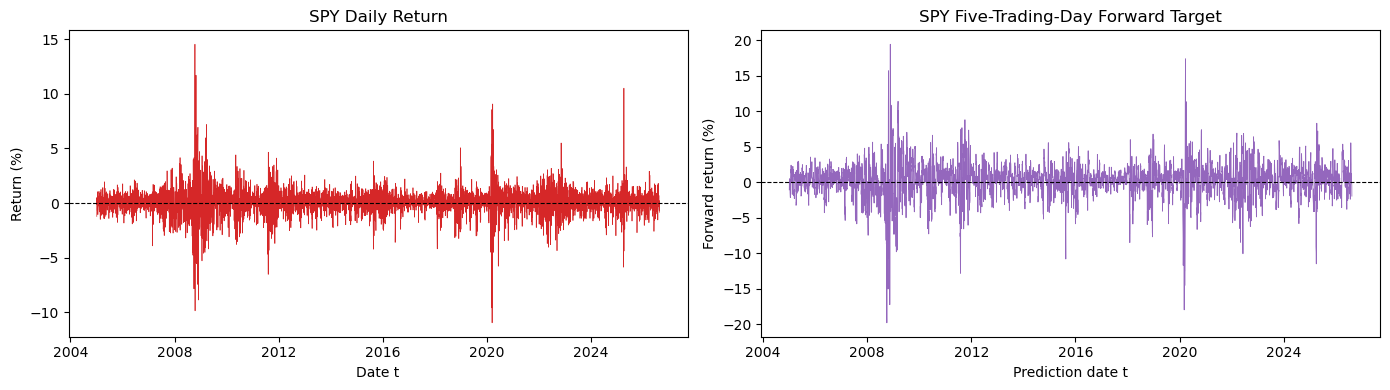

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df.index, df[DAILY_RETURN_COL] * 100, color="#d62728", linewidth=0.5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("SPY Daily Return")
axes[0].set_xlabel("Date t")
axes[0].set_ylabel("Return (%)")

axes[1].plot(df.index, df[TARGET_COL] * 100, color="#9467bd", linewidth=0.6)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("SPY Five-Trading-Day Forward Target")
axes[1].set_xlabel("Prediction date t")
axes[1].set_ylabel("Forward return (%)")
plt.tight_layout()
plt.show()


## E1-S4 [P0][Data] Build Historical Feature Set

Frozen features:

- Return/momentum: `return_1d`, `return_5d`, `return_10d`, `return_20d`, where $P_t/P_{t-n}-1$.
- Annualized realized volatility: `volatility_5d`, `volatility_10d`, `volatility_20d`, using the rolling sample standard deviation (`ddof=1`) of daily returns times $\sqrt{252}$.
- Trend: `trend_10d`, `trend_20d`, `trend_60d`, where $P_t/MA_n(P)_t-1$.
- Volume: `volume_ratio_20d`, where $Volume_t/MA_{20}(Volume)_t$.

All windows end at $t$ (`center=False`); warm-up NaNs are preserved until final alignment. No backfill, clipping, or winsorization is applied.


In [7]:
RETURN_WINDOWS = [5, 10, 20]
VOLATILITY_WINDOWS = [5, 10, 20]
TREND_WINDOWS = [10, 20, 60]

for window in RETURN_WINDOWS:
    df[f"return_{window}d"] = df["Close"] / df["Close"].shift(window) - 1

for window in VOLATILITY_WINDOWS:
    df[f"volatility_{window}d"] = (
        df[DAILY_RETURN_COL]
        .rolling(window=window, min_periods=window, center=False)
        .std(ddof=1)
        * np.sqrt(TRADING_DAYS_PER_YEAR)
    )

for window in TREND_WINDOWS:
    moving_average = df["Close"].rolling(
        window=window, min_periods=window, center=False
    ).mean()
    df[f"trend_{window}d"] = df["Close"] / moving_average - 1

volume_ma_20d = df["Volume"].rolling(window=20, min_periods=20, center=False).mean()
assert (volume_ma_20d.dropna() > 0).all(), "20-day volume denominator must be positive"
df["volume_ratio_20d"] = df["Volume"] / volume_ma_20d

FEATURE_COLUMNS = [
    "return_1d", "return_5d", "return_10d", "return_20d",
    "volatility_5d", "volatility_10d", "volatility_20d",
    "trend_10d", "trend_20d", "trend_60d",
    "volume_ratio_20d",
]

assert len(FEATURE_COLUMNS) == 11
assert len(set(FEATURE_COLUMNS)) == len(FEATURE_COLUMNS)
assert TARGET_COL not in FEATURE_COLUMNS

display(df[FEATURE_COLUMNS].tail())


,return_1d,return_5d,return_10d,return_20d,volatility_5d,volatility_10d,volatility_20d,trend_10d,trend_20d,trend_60d,volume_ratio_20d
Date,,,,,,,,,,,
2026-08-14,-0.001980,0.003983,0.039235,0.044465,0.064463,0.117187,0.133602,0.006807,0.026638,0.036917,0.668479
2026-08-17,-0.004727,-0.000466,0.019798,0.041208,0.075883,0.108595,0.135231,0.000102,0.019723,0.031250,0.744923
2026-08-18,-0.006756,-0.004036,-0.005030,0.025619,0.088277,0.070726,0.136536,-0.006155,0.011554,0.023676,0.942491
2026-08-19,0.002098,-0.004440,-0.000948,0.028967,0.087361,0.071277,0.136246,-0.003976,0.012232,0.025246,0.858043
2026-08-20,-0.008400,-0.019643,-0.007755,0.033081,0.065806,0.082597,0.131576,-0.011580,0.002119,0.016320,0.978543


In [8]:
expected_first_valid_positions = {
    "return_1d": 1,
    "return_5d": 5,
    "return_10d": 10,
    "return_20d": 20,
    "volatility_5d": 5,
    "volatility_10d": 10,
    "volatility_20d": 20,
    "trend_10d": 9,
    "trend_20d": 19,
    "trend_60d": 59,
    "volume_ratio_20d": 19,
}

for feature, expected_position in expected_first_valid_positions.items():
    actual_position = df.index.get_loc(df[feature].first_valid_index())
    assert actual_position == expected_position, (
        f"Unexpected warm-up boundary for {feature}: {actual_position}"
    )

feature_sample_positions = sorted({100, len(df) // 2, len(df) - 10})
manual_feature_records = []
for position in feature_sample_positions:
    close_t = float(df["Close"].iloc[position])
    manual_return_5d = close_t / float(df["Close"].iloc[position - 5]) - 1
    manual_volatility_20d = (
        df[DAILY_RETURN_COL].iloc[position - 19: position + 1].std(ddof=1)
        * np.sqrt(TRADING_DAYS_PER_YEAR)
    )
    manual_trend_60d = close_t / df["Close"].iloc[position - 59: position + 1].mean() - 1
    manual_volume_ratio = float(df["Volume"].iloc[position]) / df["Volume"].iloc[
        position - 19: position + 1
    ].mean()

    checks = {
        "return_5d": manual_return_5d,
        "volatility_20d": manual_volatility_20d,
        "trend_60d": manual_trend_60d,
        "volume_ratio_20d": manual_volume_ratio,
    }
    for feature, manual_value in checks.items():
        assert np.isclose(df[feature].iloc[position], manual_value, atol=1e-12, rtol=1e-12)

    manual_feature_records.append({
        "date_t": df.index[position],
        **{f"{feature}_error": abs(df[feature].iloc[position] - value) for feature, value in checks.items()},
    })

feature_quality = pd.DataFrame({
    "first_valid_date": [df[column].first_valid_index() for column in FEATURE_COLUMNS],
    "warmup_nan_rows": [int(df[column].isna().sum()) for column in FEATURE_COLUMNS],
    "min": [df[column].min() for column in FEATURE_COLUMNS],
    "max": [df[column].max() for column in FEATURE_COLUMNS],
}, index=FEATURE_COLUMNS)
feature_quality_display = feature_quality.copy()
feature_quality_display[["min", "max"]] = feature_quality_display[["min", "max"]].round(6)

assert np.isfinite(df[FEATURE_COLUMNS].dropna().to_numpy()).all()
display(pd.DataFrame(manual_feature_records).set_index("date_t"))
display(feature_quality_display)
print("✅ E1-S4 historical-only formulas and warm-up boundaries: PASS")


,return_5d_error,volatility_20d_error,trend_60d_error,volume_ratio_20d_error
date_t,,,,
2005-05-26,0.0,1.387779e-17,0.0,0.0
2015-10-23,0.0,2.775558e-17,0.0,0.0
2026-08-07,0.0,1.360023e-15,0.0,0.0


,first_valid_date,warmup_nan_rows,min,max
return_1d,2005-01-04,1,-0.109424,0.145198
return_5d,2005-01-10,5,-0.197934,0.194036
return_10d,2005-01-18,10,-0.267688,0.215805
return_20d,2005-02-01,20,-0.309868,0.236212
volatility_5d,2005-01-10,5,0.006759,1.499428
volatility_10d,2005-01-18,10,0.020075,1.127967
volatility_20d,2005-02-01,20,0.031906,0.959177
trend_10d,2005-01-14,9,-0.159742,0.085710
trend_20d,2005-01-31,19,-0.212544,0.114525
trend_60d,2005-03-30,59,-0.280135,0.160691


✅ E1-S4 historical-only formulas and warm-up boundaries: PASS


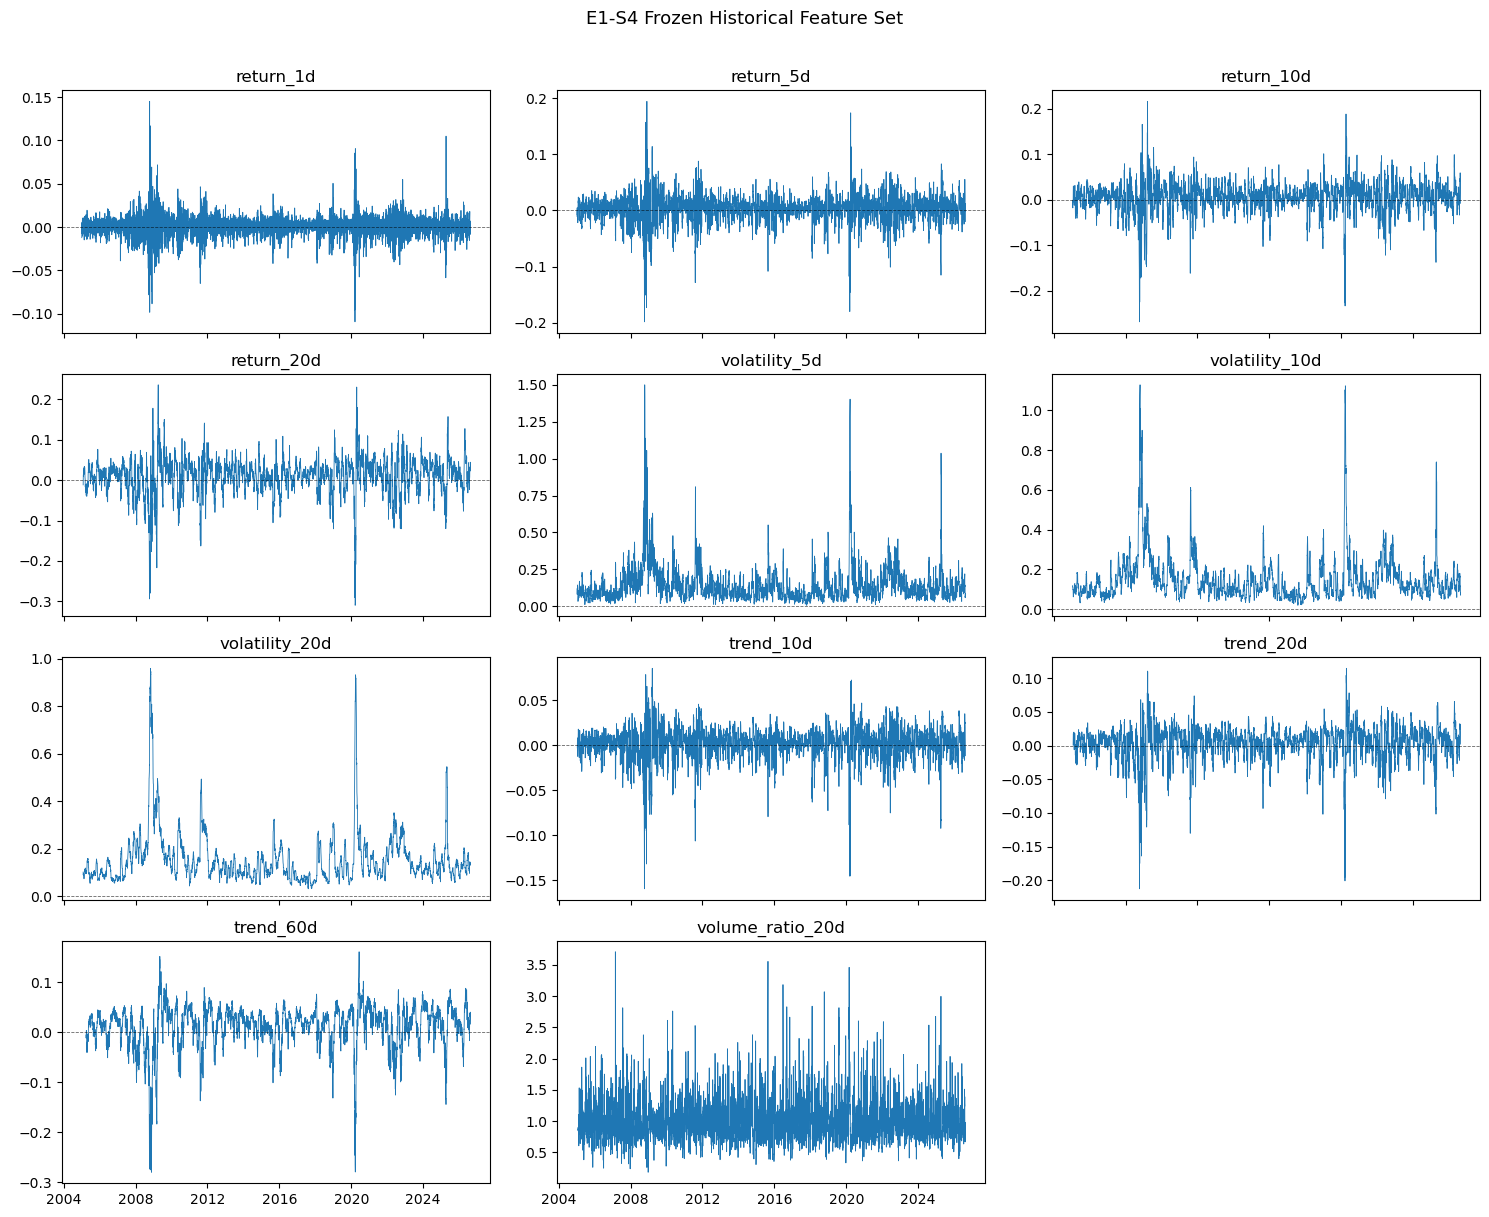

In [9]:
n_columns = 3
n_rows = int(np.ceil(len(FEATURE_COLUMNS) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 3 * n_rows), sharex=True)
axes = axes.flatten()

for axis, feature in zip(axes, FEATURE_COLUMNS):
    axis.plot(df.index, df[feature], linewidth=0.6, color="#1f77b4")
    if feature != "volume_ratio_20d":
        axis.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.6)
    axis.set_title(feature)

for axis in axes[len(FEATURE_COLUMNS):]:
    axis.set_visible(False)

fig.suptitle("E1-S4 Frozen Historical Feature Set", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


## E1-S5 [P0][Data] Construct Leakage-Safe Low/High Volatility Regime

The 20-day realized-volatility feature is compared with a pre-specified historical-only threshold:

$$threshold_t = median\{volatility\_20d_s : s < t\}$$

The threshold becomes available only after 252 prior non-null volatility observations. `HighVol` is assigned when `volatility_20d >= threshold`; otherwise the row is `LowVol`. Early rows without enough history remain missing and are excluded only at E1-S6.


In [10]:
REGIME_VOLATILITY_COL = "volatility_20d"
REGIME_THRESHOLD_COL = "historical_volatility_threshold_20d"
REGIME_COL = "regime"
MIN_HISTORICAL_VOL_OBSERVATIONS = 252

df[REGIME_THRESHOLD_COL] = (
    df[REGIME_VOLATILITY_COL]
    .expanding(min_periods=MIN_HISTORICAL_VOL_OBSERVATIONS)
    .median()
    .shift(1)
)

df[REGIME_COL] = pd.Series(pd.NA, index=df.index, dtype="string")
regime_eligible = df[[REGIME_VOLATILITY_COL, REGIME_THRESHOLD_COL]].notna().all(axis=1)
df.loc[
    regime_eligible & (df[REGIME_VOLATILITY_COL] >= df[REGIME_THRESHOLD_COL]),
    REGIME_COL,
] = "HighVol"
df.loc[
    regime_eligible & (df[REGIME_VOLATILITY_COL] < df[REGIME_THRESHOLD_COL]),
    REGIME_COL,
] = "LowVol"

assert set(df[REGIME_COL].dropna().unique()) == {"LowVol", "HighVol"}
assert df.loc[regime_eligible, REGIME_COL].notna().all()
assert df.loc[~regime_eligible, REGIME_COL].isna().all()

display(df[[REGIME_VOLATILITY_COL, REGIME_THRESHOLD_COL, REGIME_COL]].dropna().head())


,volatility_20d,historical_volatility_threshold_20d,regime
Date,,,
2006-02-01,0.097810,0.096547,HighVol
2006-02-02,0.105706,0.096571,HighVol
2006-02-03,0.107026,0.096591,HighVol
2006-02-06,0.102675,0.096611,HighVol
2006-02-07,0.105801,0.096612,HighVol


In [11]:
eligible_positions = np.flatnonzero(regime_eligible.to_numpy())
regime_check_positions = sorted({
    int(eligible_positions[0]),
    int(eligible_positions[len(eligible_positions) // 2]),
    int(eligible_positions[-1]),
})

threshold_check_records = []
for position in regime_check_positions:
    historical_volatility = df[REGIME_VOLATILITY_COL].iloc[:position].dropna()
    assert len(historical_volatility) >= MIN_HISTORICAL_VOL_OBSERVATIONS
    manual_threshold = historical_volatility.median()
    stored_threshold = df[REGIME_THRESHOLD_COL].iloc[position]
    assert np.isclose(stored_threshold, manual_threshold, atol=1e-12, rtol=1e-12)

    expected_regime = (
        "HighVol"
        if df[REGIME_VOLATILITY_COL].iloc[position] >= stored_threshold
        else "LowVol"
    )
    assert df[REGIME_COL].iloc[position] == expected_regime
    threshold_check_records.append({
        "date_t": df.index[position],
        "prior_volatility_observations": len(historical_volatility),
        "volatility_20d": df[REGIME_VOLATILITY_COL].iloc[position],
        "stored_threshold": stored_threshold,
        "manual_past_only_median": manual_threshold,
        "regime": expected_regime,
    })

regime_counts = df.loc[regime_eligible, REGIME_COL].value_counts().reindex(["LowVol", "HighVol"])
regime_report = pd.DataFrame({
    "rows": regime_counts,
    "share_pct": (regime_counts / regime_counts.sum() * 100).round(2),
})

display(pd.DataFrame(threshold_check_records).set_index("date_t").round(6))
display(regime_report)
print("Equality rule: volatility_20d == threshold → HighVol")
print("✅ E1-S5 past-only threshold, equality rule, and regime counts: PASS")


,prior_volatility_observations,volatility_20d,stored_threshold,manual_past_only_median,regime
date_t,,,,,
2006-02-01,252,0.097810,0.096547,0.096547,HighVol
2016-05-10,2837,0.092437,0.133401,0.133401,LowVol
2026-08-20,5421,0.131576,0.129083,0.129083,HighVol


,rows,share_pct
regime,,
LowVol,2590,50.1
HighVol,2580,49.9


Equality rule: volatility_20d == threshold → HighVol
✅ E1-S5 past-only threshold, equality rule, and regime counts: PASS


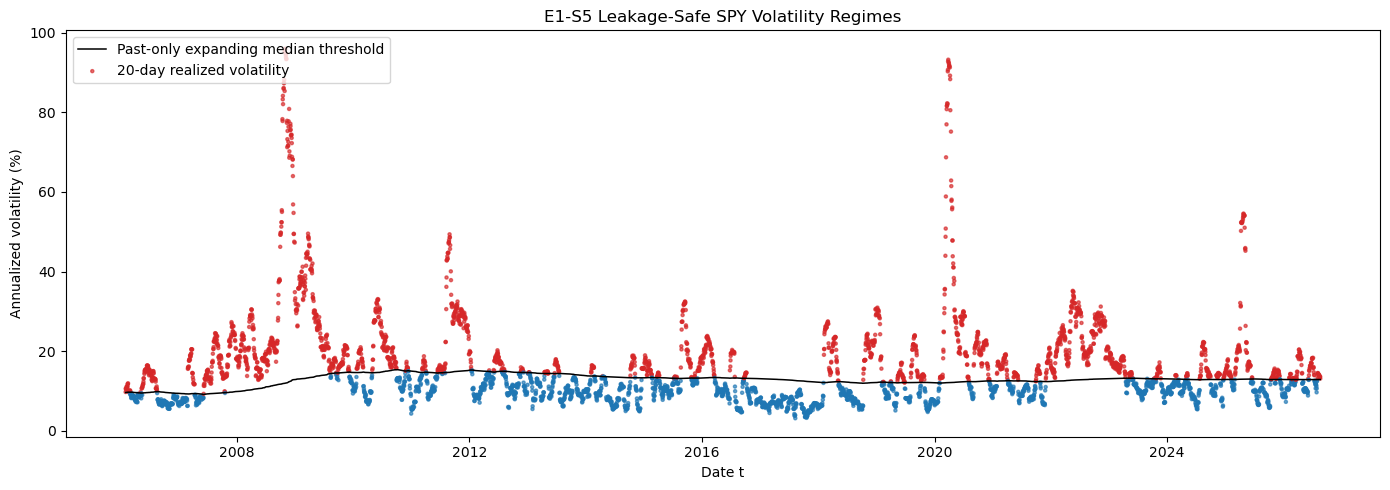

In [12]:
regime_plot_data = df[[REGIME_VOLATILITY_COL, REGIME_THRESHOLD_COL, REGIME_COL]].dropna()
regime_colors = regime_plot_data[REGIME_COL].map({"LowVol": "#1f77b4", "HighVol": "#d62728"})

fig, axis = plt.subplots(figsize=(14, 5))
axis.plot(
    regime_plot_data.index,
    regime_plot_data[REGIME_THRESHOLD_COL] * 100,
    color="black",
    linewidth=1.1,
    label="Past-only expanding median threshold",
)
axis.scatter(
    regime_plot_data.index,
    regime_plot_data[REGIME_VOLATILITY_COL] * 100,
    c=regime_colors,
    s=5,
    alpha=0.65,
    label="20-day realized volatility",
)
axis.set_title("E1-S5 Leakage-Safe SPY Volatility Regimes")
axis.set_xlabel("Date t")
axis.set_ylabel("Annualized volatility (%)")
axis.legend(loc="upper left")
plt.tight_layout()
plt.show()


## E1-S6 [P0][Data] Publish Canonical Modeling Dataset & Data Dictionary

The canonical dataset is the single source of truth for downstream modeling. It contains exactly `Date`, the frozen E1-S4 features, `forward_return_5d`, and `regime`. Warm-up, insufficient-regime-history, and unavailable-target rows are excluded together after alignment.


In [13]:
canonical_columns = ["Date", *FEATURE_COLUMNS, TARGET_COL, REGIME_COL]
canonical_indexed = df[FEATURE_COLUMNS + [TARGET_COL, REGIME_COL]].dropna().copy()
canonical_dataset = canonical_indexed.reset_index()
canonical_dataset = canonical_dataset[canonical_columns]

numeric_modeling_columns = FEATURE_COLUMNS + [TARGET_COL]
canonical_dataset[numeric_modeling_columns] = canonical_dataset[numeric_modeling_columns].astype("float64")
canonical_dataset[REGIME_COL] = canonical_dataset[REGIME_COL].astype("string")
canonical_dataset["Date"] = pd.to_datetime(canonical_dataset["Date"])

data_dictionary_records = [
    {
        "column": "Date",
        "role": "identifier",
        "dtype": "datetime64[ns]",
        "formula": "SPY trading date",
        "window": "none",
        "timestamp_semantics": "prediction date t",
        "unit": "date",
        "missing_value_policy": "not allowed in canonical rows",
        "source": "E1-S1 immutable SPY raw artifact",
    },
    {
        "column": "return_1d",
        "role": "feature",
        "dtype": "float64",
        "formula": "Close_t / Close_(t-1) - 1",
        "window": "1 trading observation",
        "timestamp_semantics": "uses prices through t only",
        "unit": "decimal return",
        "missing_value_policy": "warm-up row excluded at E1-S6",
        "source": "auto-adjusted Close",
    },
]

for window in RETURN_WINDOWS:
    data_dictionary_records.append({
        "column": f"return_{window}d",
        "role": "feature",
        "dtype": "float64",
        "formula": f"Close_t / Close_(t-{window}) - 1",
        "window": f"{window} trading observations",
        "timestamp_semantics": "uses prices through t only",
        "unit": "decimal return",
        "missing_value_policy": "warm-up rows excluded at E1-S6",
        "source": "auto-adjusted Close",
    })

for window in VOLATILITY_WINDOWS:
    data_dictionary_records.append({
        "column": f"volatility_{window}d",
        "role": "feature",
        "dtype": "float64",
        "formula": f"std(return_1d[t-{window-1}:t], ddof=1) * sqrt(252)",
        "window": f"{window} trading observations",
        "timestamp_semantics": "right-aligned; uses returns through t only",
        "unit": "annualized decimal volatility",
        "missing_value_policy": "warm-up rows excluded at E1-S6",
        "source": "derived from return_1d",
    })

for window in TREND_WINDOWS:
    data_dictionary_records.append({
        "column": f"trend_{window}d",
        "role": "feature",
        "dtype": "float64",
        "formula": f"Close_t / mean(Close[t-{window-1}:t]) - 1",
        "window": f"{window} trading observations",
        "timestamp_semantics": "right-aligned; uses prices through t only",
        "unit": "decimal ratio minus one",
        "missing_value_policy": "warm-up rows excluded at E1-S6",
        "source": "auto-adjusted Close",
    })

data_dictionary_records.extend([
    {
        "column": "volume_ratio_20d",
        "role": "feature",
        "dtype": "float64",
        "formula": "Volume_t / mean(Volume[t-19:t])",
        "window": "20 trading observations",
        "timestamp_semantics": "right-aligned; uses volume through t only",
        "unit": "ratio",
        "missing_value_policy": "warm-up rows excluded at E1-S6",
        "source": "SPY Volume",
    },
    {
        "column": TARGET_COL,
        "role": "target",
        "dtype": "float64",
        "formula": "Close_(t+5) / Close_t - 1",
        "window": "5 subsequent trading observations",
        "timestamp_semantics": "label attached to prediction date t; never enters X",
        "unit": "decimal forward return",
        "missing_value_policy": "final five unavailable labels excluded at E1-S6",
        "source": "auto-adjusted Close",
    },
    {
        "column": REGIME_COL,
        "role": "segment label",
        "dtype": "string",
        "formula": "HighVol if volatility_20d >= median(prior volatility_20d); else LowVol",
        "window": "20-day volatility + expanding past-only threshold (min 252 observations)",
        "timestamp_semantics": "threshold excludes current and all future rows",
        "unit": "{LowVol, HighVol}",
        "missing_value_policy": "insufficient-history rows excluded at E1-S6",
        "source": "derived from volatility_20d",
    },
])

data_dictionary = pd.DataFrame(data_dictionary_records)
data_dictionary = data_dictionary.set_index("column").loc[canonical_columns].reset_index()

CANONICAL_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
DATA_DICTIONARY_PATH.parent.mkdir(parents=True, exist_ok=True)
canonical_dataset.to_csv(CANONICAL_CSV_PATH, index=False, date_format="%Y-%m-%d")
data_dictionary.to_csv(DATA_DICTIONARY_PATH, index=False)

display(canonical_dataset.head())
display(canonical_dataset.tail())
display(data_dictionary)


,Date,return_1d,return_5d,return_10d,return_20d,volatility_5d,volatility_10d,volatility_20d,trend_10d,trend_20d,trend_60d,volume_ratio_20d,forward_return_5d,regime
0,2006-02-01,0.006981,0.013659,0.004459,0.013339,0.107045,0.127318,0.097810,0.007660,0.003882,0.019202,1.038396,-0.013786,HighVol
1,2006-02-02,-0.011605,-0.003612,-0.010989,-0.003142,0.142215,0.138967,0.105706,-0.002931,-0.007613,0.006650,1.331700,-0.003861,HighVol
2,2006-02-03,-0.004965,-0.017660,0.002382,-0.008714,0.112157,0.104837,0.107026,-0.008115,-0.012111,0.001033,1.329143,0.002930,HighVol
3,2006-02-06,0.002614,-0.014326,0.001424,-0.014326,0.119742,0.104096,0.102675,-0.005663,-0.008816,0.002985,0.712626,-0.001501,HighVol
4,2006-02-07,-0.008847,-0.015843,-0.008455,-0.025550,0.123752,0.113200,0.105801,-0.013631,-0.016318,-0.006379,1.091327,0.018091,HighVol


,Date,return_1d,return_5d,return_10d,return_20d,volatility_5d,volatility_10d,volatility_20d,trend_10d,trend_20d,trend_60d,volume_ratio_20d,forward_return_5d,regime
5160,2026-08-07,0.006115,0.035112,0.046459,0.024253,0.144130,0.161880,0.143750,0.025715,0.030776,0.036906,0.876656,0.003983,HighVol
5161,2026-08-10,-0.000297,0.020273,0.045921,0.031849,0.134474,0.162289,0.140037,0.020814,0.028834,0.035843,0.793230,-0.000466,HighVol
5162,2026-08-11,-0.003195,-0.000998,0.040089,0.024913,0.058352,0.166730,0.140839,0.013577,0.024270,0.031973,0.741328,-0.004036,HighVol
5163,2026-08-12,0.002505,0.003507,0.058989,0.023423,0.058343,0.128269,0.140564,0.010397,0.025630,0.033745,0.676748,-0.004440,HighVol
5164,2026-08-13,0.006977,0.012127,0.048794,0.036179,0.067978,0.113331,0.139712,0.012654,0.030927,0.040004,0.734907,-0.019643,HighVol


,column,role,dtype,formula,window,timestamp_semantics,unit,missing_value_policy,source
0,Date,identifier,datetime64[ns],SPY trading date,none,prediction date t,date,not allowed in canonical rows,E1-S1 immutable SPY raw artifact
1,return_1d,feature,float64,Close_t / Close_(t-1) - 1,1 trading observation,uses prices through t only,decimal return,warm-up row excluded at E1-S6,auto-adjusted Close
2,return_5d,feature,float64,Close_t / Close_(t-5) - 1,5 trading observations,uses prices through t only,decimal return,warm-up rows excluded at E1-S6,auto-adjusted Close
3,return_10d,feature,float64,Close_t / Close_(t-10) - 1,10 trading observations,uses prices through t only,decimal return,warm-up rows excluded at E1-S6,auto-adjusted Close
4,return_20d,feature,float64,Close_t / Close_(t-20) - 1,20 trading observations,uses prices through t only,decimal return,warm-up rows excluded at E1-S6,auto-adjusted Close
5,volatility_5d,feature,float64,"std(return_1d[t-4:t], ddof=1) * sqrt(252)",5 trading observations,right-aligned; uses returns through t only,annualized decimal volatility,warm-up rows excluded at E1-S6,derived from return_1d
6,volatility_10d,feature,float64,"std(return_1d[t-9:t], ddof=1) * sqrt(252)",10 trading observations,right-aligned; uses returns through t only,annualized decimal volatility,warm-up rows excluded at E1-S6,derived from return_1d
7,volatility_20d,feature,float64,"std(return_1d[t-19:t], ddof=1) * sqrt(252)",20 trading observations,right-aligned; uses returns through t only,annualized decimal volatility,warm-up rows excluded at E1-S6,derived from return_1d
8,trend_10d,feature,float64,Close_t / mean(Close[t-9:t]) - 1,10 trading observations,right-aligned; uses prices through t only,decimal ratio minus one,warm-up rows excluded at E1-S6,auto-adjusted Close
9,trend_20d,feature,float64,Close_t / mean(Close[t-19:t]) - 1,20 trading observations,right-aligned; uses prices through t only,decimal ratio minus one,warm-up rows excluded at E1-S6,auto-adjusted Close


In [14]:
# Independent reload plus schema, alignment, dtype, and integrity checks
reloaded_canonical = pd.read_csv(CANONICAL_CSV_PATH, parse_dates=["Date"])
reloaded_dictionary = pd.read_csv(DATA_DICTIONARY_PATH)

assert list(reloaded_canonical.columns) == canonical_columns
assert list(reloaded_dictionary["column"]) == canonical_columns
assert len(reloaded_canonical) == len(canonical_dataset)
assert reloaded_canonical["Date"].is_monotonic_increasing
assert reloaded_canonical["Date"].is_unique
assert not reloaded_canonical.isna().any().any()
assert np.isfinite(reloaded_canonical[numeric_modeling_columns].to_numpy()).all()
assert set(reloaded_canonical[REGIME_COL].unique()) == {"LowVol", "HighVol"}
assert TARGET_COL not in FEATURE_COLUMNS
assert canonical_indexed.index.equals(
    df.loc[canonical_indexed.index, FEATURE_COLUMNS + [TARGET_COL, REGIME_COL]].index
)
assert set(reloaded_canonical[REGIME_COL]) == set(canonical_dataset[REGIME_COL])

pd.testing.assert_frame_equal(
    df[OHLCV_COLUMNS],
    raw_ohlcv_snapshot,
    check_dtype=True,
    check_exact=True,
)

for column in numeric_modeling_columns:
    assert np.allclose(
        reloaded_canonical[column].to_numpy(),
        canonical_dataset[column].to_numpy(),
        atol=1e-14,
        rtol=1e-12,
    ), f"CSV round-trip mismatch in {column}"

canonical_sha256 = hashlib.sha256(CANONICAL_CSV_PATH.read_bytes()).hexdigest()
dictionary_sha256 = hashlib.sha256(DATA_DICTIONARY_PATH.read_bytes()).hexdigest()
manifest = {
    "card": "E1-S6 [P0][Data] Publish Canonical Modeling Dataset & Data Dictionary",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "E1-S3_to_E1-S6_Data_Foundation_and_Regime_Construction.ipynb",
    "source_raw_path": str(RAW_CSV_PATH.relative_to(PROJECT_ROOT)),
    "source_raw_sha256": raw_sha256,
    "canonical_path": str(CANONICAL_CSV_PATH.relative_to(PROJECT_ROOT)),
    "canonical_sha256": canonical_sha256,
    "data_dictionary_path": str(DATA_DICTIONARY_PATH.relative_to(PROJECT_ROOT)),
    "data_dictionary_sha256": dictionary_sha256,
    "rows": int(len(reloaded_canonical)),
    "columns": canonical_columns,
    "first_date": reloaded_canonical["Date"].min().date().isoformat(),
    "last_date": reloaded_canonical["Date"].max().date().isoformat(),
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COL,
    "regime_column": REGIME_COL,
    "regime_threshold": {
        "volatility_column": REGIME_VOLATILITY_COL,
        "method": "expanding median of values strictly before t",
        "minimum_prior_observations": MIN_HISTORICAL_VOL_OBSERVATIONS,
        "equality_rule": "HighVol",
    },
    "python": platform.python_version(),
    "package_versions": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "yfinance": yf.__version__,
    },
}
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")

quality_gate = pd.DataFrame([
    ["Sorted unique Date", True, f"{len(reloaded_canonical):,} unique rows"],
    ["No NaN in admitted rows", not reloaded_canonical.isna().any().any(), "0 missing cells"],
    ["No inf in numeric columns", np.isfinite(reloaded_canonical[numeric_modeling_columns]).all().all(), "all numeric values finite"],
    ["Feature/target/regime alignment", len(reloaded_canonical) == len(canonical_indexed), "single shared row index before reset"],
    ["Target excluded from X", TARGET_COL not in FEATURE_COLUMNS, f"{len(FEATURE_COLUMNS)} frozen features"],
    ["Raw OHLCV unchanged", True, raw_sha256],
    ["Data dictionary coverage", list(reloaded_dictionary["column"]) == canonical_columns, f"{len(canonical_columns)} of {len(canonical_columns)} columns"],
], columns=["check", "passed", "evidence"])

assert quality_gate["passed"].all()
display(quality_gate)
print(f"Canonical dataset: {CANONICAL_CSV_PATH.relative_to(PROJECT_ROOT)}")
print(f"Data dictionary: {DATA_DICTIONARY_PATH.relative_to(PROJECT_ROOT)}")
print(f"Manifest: {MANIFEST_PATH.relative_to(PROJECT_ROOT)}")
print(f"Canonical SHA-256: {canonical_sha256}")
print("✅ E1-S6 canonical dataset and data dictionary quality gate: PASS")


,check,passed,evidence
0,Sorted unique Date,True,"5,165 unique rows"
1,No NaN in admitted rows,True,0 missing cells
2,No inf in numeric columns,True,all numeric values finite
3,Feature/target/regime alignment,True,single shared row index before reset
4,Target excluded from X,True,11 frozen features
5,Raw OHLCV unchanged,True,1007a7421e108dd8f9290e739540211291a5445ca21ed1...
6,Data dictionary coverage,True,14 of 14 columns


Canonical dataset: data/processed/E1-S6_canonical_modeling_dataset.csv
Data dictionary: docs/E1-S6_data_dictionary.csv
Manifest: data/processed/E1-S6_dataset_manifest.json
Canonical SHA-256: 96f79c15ff277bf0a8f8107a6313ac86e85888d4dbdbe7f7bd4ddc0c297b4da6
✅ E1-S6 canonical dataset and data dictionary quality gate: PASS


## Takeaways

- E1-S3 through E1-S6 produce one deterministic modeling table with **5,165 rows** and **14 columns**.
- Every feature is right-aligned to prediction date $t$ and uses information at or before $t$; the target uses $t+5$ only as `y`.
- The historical volatility threshold excludes the current and all future observations. The early threshold warm-up and final five unavailable labels are excluded together at the canonical alignment step.
- The committed raw artifact, processed dataset, data dictionary, and manifest hashes make provider revisions and stale-output mismatches visible.
- This notebook establishes the data foundation only. LightGBM fitting, walk-forward purging, and OOS evaluation remain in E2.
